# 🔬 Analyse Comparative GRL vs Triplet
Ce notebook permet d'agréger tous les scores (Kappa et ROC-AUC) et de générer les visualisations pour le rapport final.

In [13]:
import pandas as pd
import plotly.express as px
import os
import glob
from sklearn.metrics import cohen_kappa_score, roc_auc_score

GRL_METRIC = "ROC-AUC"  # Options: "Kappa" ou "ROC-AUC"


def create_empty_config(m_type):
    cfg = []
    scopes = [("No Mask", "Yes"), ("Manual Crop", "No"), ("Manual Crop Tensor", "No")]
    
    id_counter = 1
    for scope, grl in scopes:
        for split in ["Géo Split", "Random (All)"]:
            cfg.append({
                "ID": id_counter,
                "Type": m_type,
                "Scope": scope,
                "GRL": grl,
                "Split": split,
                "Kappa": 0.0,
                "ROC-AUC": 0.0
            })
            id_counter += 1
    return cfg

def collect_data(df_cfg):
    results_path = "../evaluation_results"
    csv_files = glob.glob(os.path.join(results_path, "**", "predictions.csv"), recursive=True)
    
    for f in csv_files:
        parts = f.split(os.sep)
        if len(parts) < 6: continue
        
        m_path = parts[-6].upper()
        s_path = parts[-5].replace("_", " ").title() # ex: "Manual Crop Tensor"
        g_path = "Yes" if "with_grl" in parts[-4] else "No"
        spl_path = "Random (All)" if "all" in parts[-2].lower() else "Géo Split"
        
        for idx, row in df_cfg.iterrows():
            # 🟢 CORRECTION : Égalité stricte au lieu de "in"
            if row["Type"].upper() in m_path and \
               row["GRL"] == g_path and \
               row["Split"] == spl_path and \
               row["Scope"].lower() == s_path.lower():
                
                try:
                    df_p = pd.read_csv(f)
                    kappa = cohen_kappa_score(df_p['True_Label'], df_p['Pred_Label'])
                    roc = 0.0
                    if len(df_p['Score'].unique()) > 2:
                        roc = roc_auc_score(df_p['True_Label'], df_p['Score'])
                    
                    df_cfg.at[idx, "Kappa"] = round(float(kappa), 3)
                    df_cfg.at[idx, "ROC-AUC"] = round(float(roc), 3)
                except: pass
    return df_cfg

# --- TRAITEMENT GRL ---
df_grl = collect_data(pd.DataFrame(create_empty_config("GRL")))
print(f"📊 RÉSULTATS GRL (Métrique sélectionnée : {GRL_METRIC})")
display(df_grl[["ID", "Scope", "Split", "Kappa", "ROC-AUC"]])

fig_grl = px.bar(df_grl, x="ID", y=GRL_METRIC, text=GRL_METRIC, 
                 title=f"Modèles GRL (1-6) - Performance {GRL_METRIC}",
                 labels={"ID": "Modele #", GRL_METRIC: f"Score {GRL_METRIC}"},
                 range_y=[0, 1], template="plotly_white", color_discrete_sequence=["#636EFA"])
fig_grl.update_traces(textposition="outside")
fig_grl.write_image("../rapport/comparison_grl.png", scale=2)
fig_grl.show()

# --- TRAITEMENT TRIPLET ---
df_triplet = collect_data(pd.DataFrame(create_empty_config("Triplet")))
# Pour Triplet, le ROC-AUC est la métrique native
print(f"\n📊 RÉSULTATS TRIPLET (Focus ROC-AUC)")
display(df_triplet[["ID", "Scope", "Split", "ROC-AUC"]])

fig_triplet = px.bar(df_triplet, x="ID", y="ROC-AUC", text="ROC-AUC", 
                     title="Modèles Triplet (1-6) - Performance ROC-AUC",
                     labels={"ID": "Modele #", "ROC-AUC": "ROC-AUC Score"},
                     range_y=[0, 1], template="plotly_white", color_discrete_sequence=["#EF553B"])
fig_triplet.update_traces(textposition="outside")
fig_triplet.write_image("../rapport/comparison_triplet.png", scale=2)
fig_triplet.show()

📊 RÉSULTATS GRL (Métrique sélectionnée : ROC-AUC)


,ID,Scope,Split,Kappa,ROC-AUC
0,1,No Mask,Géo Split,0.541,0.833
1,2,No Mask,Random (All),0.771,0.956
2,3,Manual Crop,Géo Split,0.236,0.714
3,4,Manual Crop,Random (All),0.769,0.959
4,5,Manual Crop Tensor,Géo Split,0.451,0.763
5,6,Manual Crop Tensor,Random (All),0.671,0.863



📊 RÉSULTATS TRIPLET (Focus ROC-AUC)


,ID,Scope,Split,ROC-AUC
0,1,No Mask,Géo Split,0.820
1,2,No Mask,Random (All),0.949
2,3,Manual Crop,Géo Split,0.839
3,4,Manual Crop,Random (All),0.873
4,5,Manual Crop Tensor,Géo Split,0.660
5,6,Manual Crop Tensor,Random (All),0.838


## 🔍 Comparaison du Grid Search - Modèles Siamois (Triplet Loss)

,Latent_Dim,LR,Margin,ROC-AUC
10,64.0,0.00010,1.0,0.9428
11,16.0,0.00010,1.0,0.9368
13,16.0,0.00100,0.2,0.9225
22,64.0,0.00001,1.0,0.9185
20,16.0,0.00100,1.0,0.9174
17,16.0,0.00001,1.0,0.9123
15,64.0,0.00100,1.0,0.9055
18,64.0,0.00100,0.2,0.8923
8,16.0,0.00010,0.2,0.8825
5,64.0,0.00010,0.2,0.8597


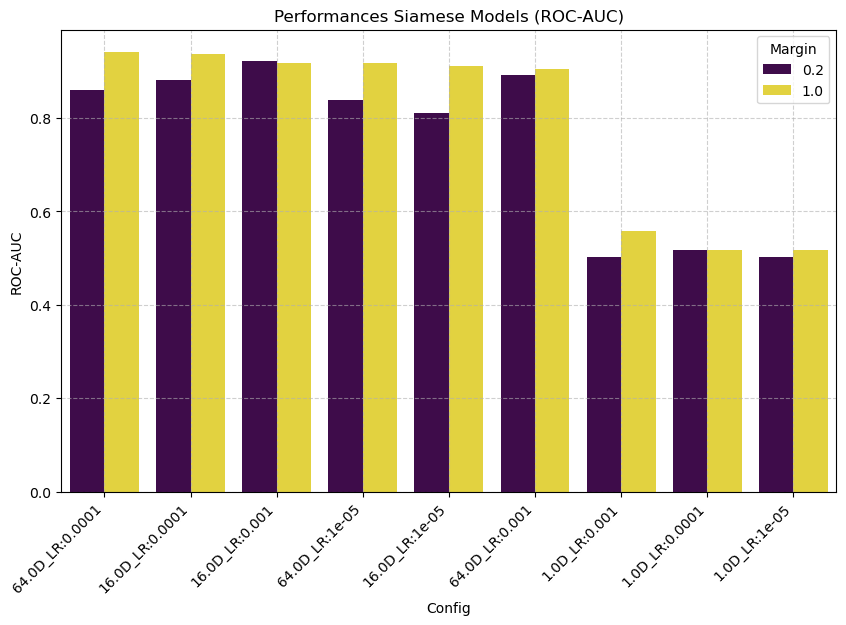

In [7]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

triplet_summaries = glob.glob("../models/triplet/**/train_summary.txt", recursive=True)

data_triplet = []
for p in triplet_summaries:
    row = {"Path": p}
    with open(p, "r", encoding="utf-8") as f:
        for line in f:
            if "Meilleure ROC-AUC Validation" in line:
                row["ROC-AUC"] = float(line.split(":")[1].strip())
            elif "Latent Dim:" in line:
                row["Latent_Dim"] = int(line.split(":")[1].strip())
            elif "Learning Rate:" in line:
                row["LR"] = float(line.split(":")[1].strip())
            elif "Margin:" in line:
                row["Margin"] = float(line.split(":")[1].strip())
            elif "GRL:" in line:
                row["GRL"] = line.split(":")[1].strip()
    if "ROC-AUC" in row:
        data_triplet.append(row)

df_triplet = pd.DataFrame(data_triplet)
# CORRECTION ICI : on supprime les espaces au début de la ligne
df_triplet = df_triplet.dropna(subset=['Latent_Dim', 'LR'])

for col in ["Latent_Dim", "LR", "Margin", "ROC-AUC"]:
    if col not in df_triplet.columns:
        df_triplet[col] = "N/A"

if not df_triplet.empty:
    df_triplet = df_triplet.sort_values("ROC-AUC", ascending=False)
    display(df_triplet[["Latent_Dim", "LR", "Margin", "ROC-AUC"]].head(30))
    
    plt.figure(figsize=(10, 6))
    df_triplet['Config'] = df_triplet['Latent_Dim'].astype(str) + 'D_LR:' + df_triplet['LR'].astype(str)
    sns.barplot(data=df_triplet, x='Config', y='ROC-AUC', hue='Margin', palette='viridis')
    plt.xticks(rotation=45, ha='right')
    plt.title("Performances Siamese Models (ROC-AUC)")
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()
else:
    print("Aucun modèle Siamois trouvé dans les logs.")

## 🔍 Comparaison du Grid Search - Modèles CNN (GRL)

,Backbone,LR,Dropout,Freeze,Kappa
22,False,0.00010,0.5,N/A,0.7856
12,False,0.00001,0.5,N/A,0.7756
18,False,0.00010,0.5,N/A,0.7671
11,False,0.00010,0.2,N/A,0.7662
24,False,0.00010,0.5,N/A,0.7653
14,False,0.00001,0.2,N/A,0.7545
25,False,0.00010,0.5,N/A,0.7532
23,True,0.00100,0.5,N/A,0.7450
17,True,0.00010,0.2,N/A,0.7402
19,True,0.00100,0.2,N/A,0.7342


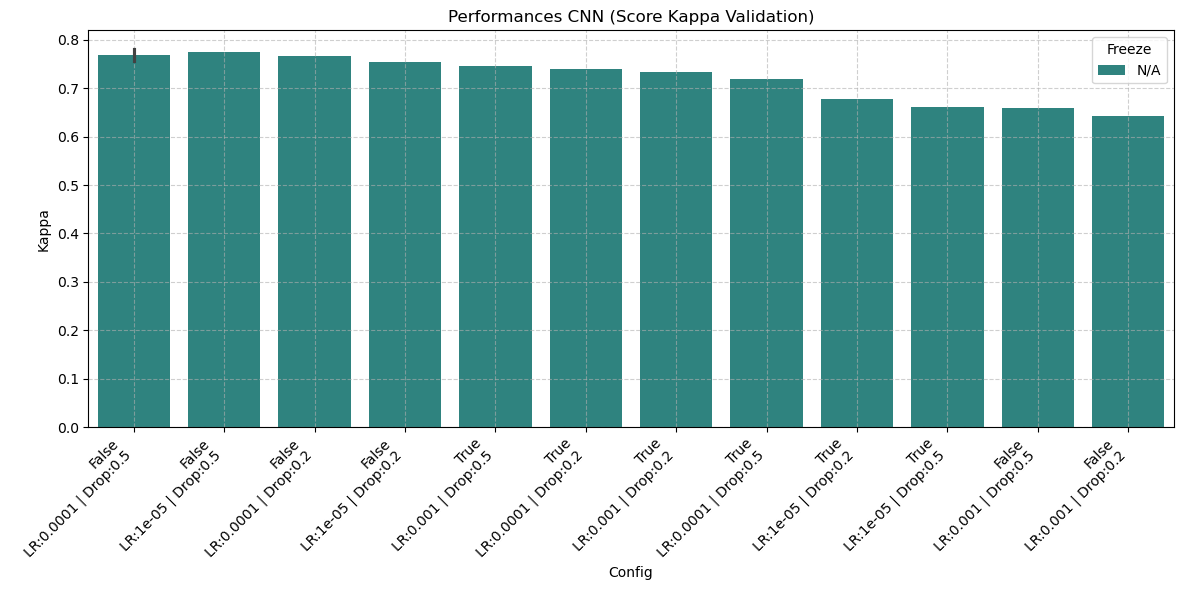

In [10]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

grl_summaries = glob.glob("../models/grl/**/train_summary.txt", recursive=True)

data_grl = []
for p in grl_summaries:
    row = {"Path": p}
    with open(p, "r", encoding="utf-8") as f:
        for line in f:
            if "Meilleur Kappa Validation" in line:
                row["Kappa"] = float(line.split(":")[1].strip())
            elif "Backbone:" in line:
                row["Backbone"] = line.split(":")[1].strip()
            elif "Dropout:" in line:
                row["Dropout"] = float(line.split(":")[1].strip())
            elif "Freeze Backbone:" in line:
                row["Freeze"] = line.split(":")[1].strip()
            elif "Learning Rate:" in line:
                row["LR"] = float(line.split(":")[1].strip())
    if "Kappa" in row:
        data_grl.append(row)

df_grl = pd.DataFrame(data_grl)
df_grl = df_grl.dropna(subset=['Backbone', 'LR'])

for col in ["Backbone", "LR", "Dropout", "Freeze", "Kappa"]:
    if col not in df_grl.columns:
        df_grl[col] = "N/A"

if not df_grl.empty:
    df_grl = df_grl.sort_values("Kappa", ascending=False)
    display(df_grl[["Backbone", "LR", "Dropout", "Freeze", "Kappa"]].head(40))
    
    # --- MODIFICATIONS GRAPHIQUES ICI ---
    plt.figure(figsize=(12, 6))
    
    # Création de la colonne Config pour regrouper les infos sur l'axe X
    df_grl['Config'] = df_grl['Backbone'].astype(str) + '\nLR:' + df_grl['LR'].astype(str) + ' | Drop:' + df_grl['Dropout'].astype(str)
    
    sns.barplot(data=df_grl, x="Config", y="Kappa", hue="Freeze", palette="viridis")
    
    plt.title("Performances CNN (Score Kappa Validation)")
    plt.xticks(rotation=45, ha='right') # Alignement propre à 45 degrés
    plt.grid(True, linestyle="--", alpha=0.6) # Ajout de la grille
    plt.tight_layout()
    plt.show()
else:
    print("Aucun log de Grid Search CNN trouvé.")